In [14]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable
from boulder_statistics.analysis.quick_calculate import FittingFunction
from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [15]:
manual_db = pl.read_parquet(r".database\manual_detection_database.parquet")
auto_db = dp.combined_mask.filter(pl.col("face") == "posx").collect()

manual_db

i,j,manual_detect_boulder_id,face
i32,i32,u32,str
7661,5626,8092974,"""posx"""
7661,5627,8092974,"""posx"""
7661,5628,8092974,"""posx"""
7661,5629,8092974,"""posx"""
7661,5630,8092974,"""posx"""
…,…,…,…
40,2454,11742965,"""posx"""
40,2455,11742965,"""posx"""
40,2456,11742965,"""posx"""


In [16]:
# shape = (8192, 8192)

# manual_img = np.zeros(shape, dtype=np.uint8)
# auto_img = np.zeros(shape, dtype=np.uint8)

# manual_img[
#     manual_db["i"].to_numpy(),
#     manual_db["j"].to_numpy()
# ] = 255

# auto_img[
#     auto_db["i"].to_numpy(),
#     auto_db["j"].to_numpy()
# ] = 255

# intersection_img = np.where(
#     (manual_img == 255) & (auto_img == 255),
#     255,
#     0,
# ).astype(np.uint8)

# non_intersection_img = np.where(
#     manual_img != auto_img,
#     255,
#     0,
# ).astype(np.uint8)

# fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# plots = [
#     (manual_img, "Manual"),
#     (auto_img, "Automatic"),
#     (intersection_img, "Intersection"),
#     (non_intersection_img, "Non-intersection"),
# ]

# for ax, (img, title) in zip(axes.ravel(), plots):
#     ax.imshow(img, cmap="gray", vmin=0, vmax=255)
#     ax.set_title(title)
#     ax.axis("off")

# plt.tight_layout()
# plt.show()

In [17]:
auto_db_agg = auto_db.group_by("row_id").agg(pl.len().alias("auto_boulder_size"))
manual_db_agg = manual_db.group_by("manual_detect_boulder_id").agg(pl.len().alias("manual_boulder_size"))

db_intersections = manual_db.join(
    auto_db,
    on=["i", "j"],
    how="inner",
).select("i", "j", "lod_level", "lod_code", "row_id", "manual_detect_boulder_id")

db_intersections

i,j,lod_level,lod_code,row_id,manual_detect_boulder_id
i32,i32,u8,str,u32,u32
352,3200,0,"""""",13,2988730
352,3201,0,"""""",13,2988730
352,3202,0,"""""",13,2988730
352,3203,0,"""""",13,2988730
352,3204,0,"""""",13,2988730
…,…,…,…,…,…
7185,7880,4,"""DDDB""",3870233,5788426
7186,7879,4,"""DDDB""",3870233,5788426
7186,7880,4,"""DDDB""",3870233,5788426


In [18]:
db_intersections_agg = db_intersections.group_by("manual_detect_boulder_id", "row_id").agg(
    pl.len().alias("overlap"),
    pl.col("lod_level").first(),
    pl.col("lod_code").first()
)

db_jaccard = db_intersections_agg.join(
    auto_db_agg,
    on="row_id",
    how="left",
).join(
    manual_db_agg,
    on="manual_detect_boulder_id",
    how="left",
).with_columns(
    (
        pl.col("overlap") / (pl.col("auto_boulder_size") + pl.col("manual_boulder_size") - pl.col("overlap"))
    ).alias("Jaccard_index")
)

db_jaccard

manual_detect_boulder_id,row_id,overlap,lod_level,lod_code,auto_boulder_size,manual_boulder_size,Jaccard_index
u32,u32,u32,u8,str,u32,u32,f64
8092974,270,18585,0,"""""",28672,23444,0.554263
14172940,1965624,71,4,"""CAAA""",71,79858,0.000889
14172940,1965685,64,4,"""CAAA""",747,79858,0.000795
14172940,1981061,39,4,"""CAAB""",39,79858,0.000488
12460721,1981181,79,4,"""CAAB""",79,57084,0.001384
…,…,…,…,…,…,…,…
6358166,3258322,40,4,"""DBBA""",40,107075,0.000374
11000215,3622458,264,3,"""DCD""",264,60682,0.004351
8092974,3634741,115,4,"""DCDA""",115,23444,0.004905


In [ ]:
db_jaccard_agg = db_jaccard.group_by("manual_detect_boulder_id").agg(
    pl.all().get(
        pl.col("Jaccard_index").arg_max()
    )
)

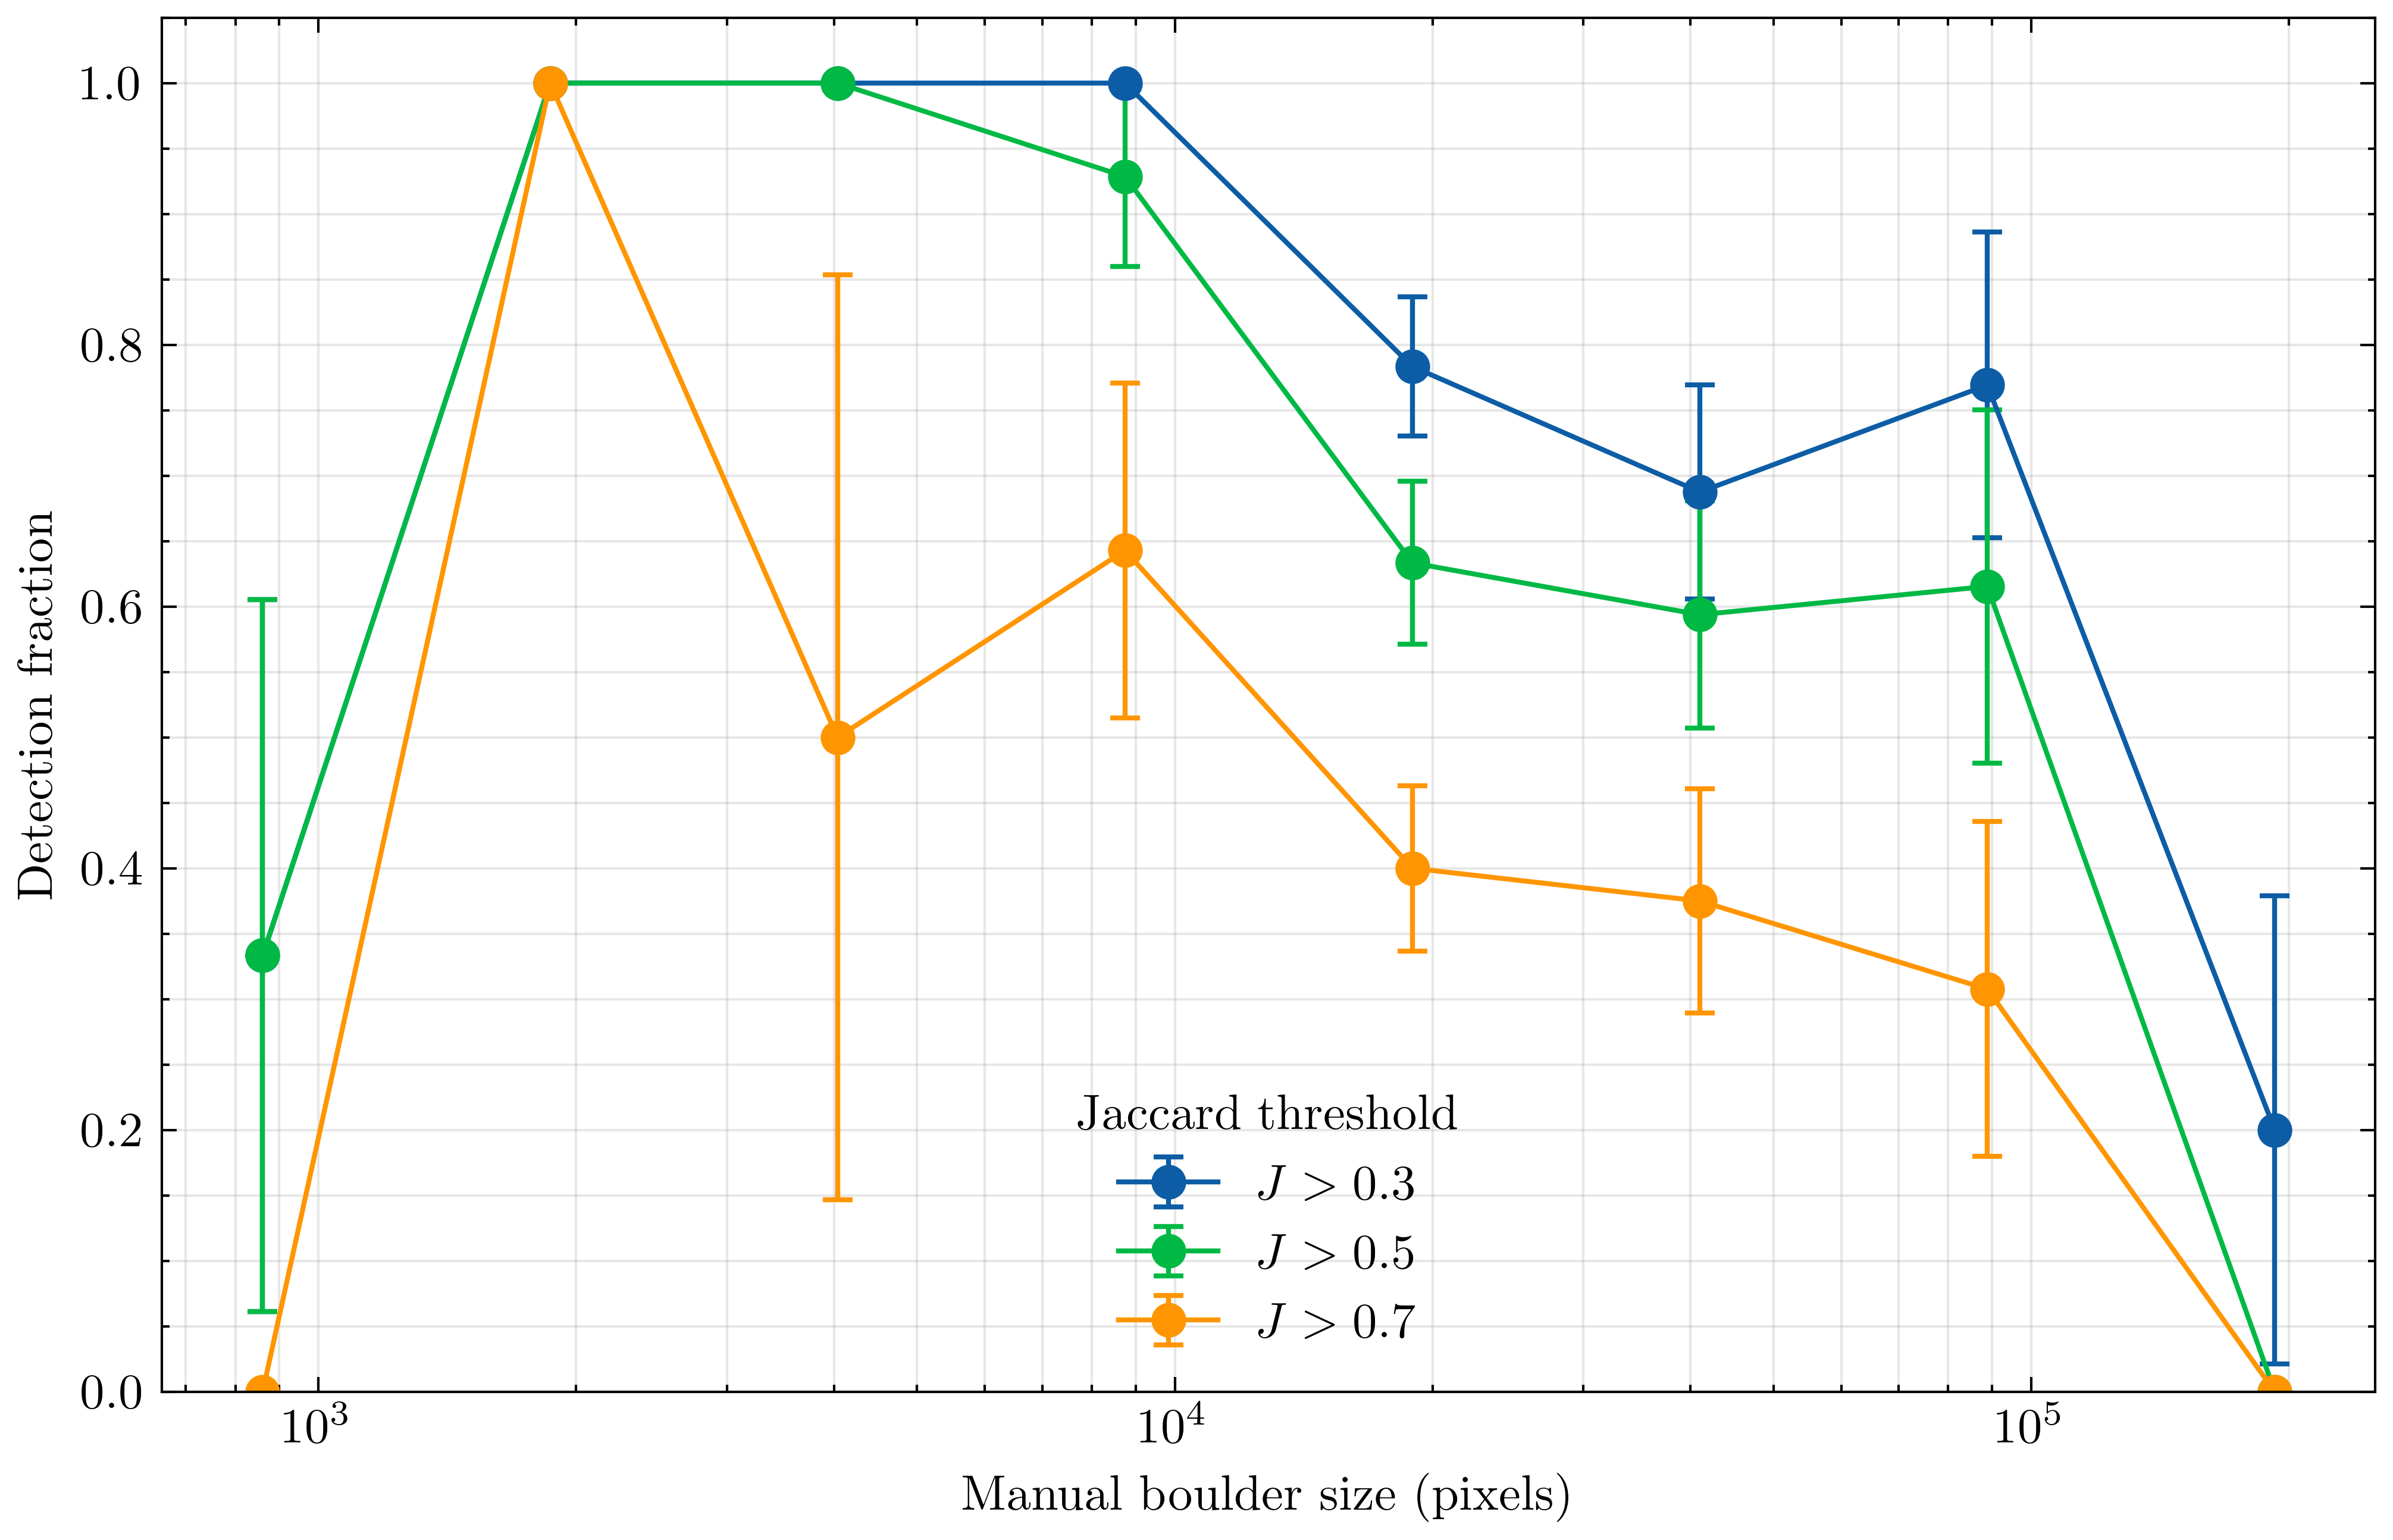

In [30]:
import numpy as np
import matplotlib.pyplot as plt

x = db_jaccard_agg["manual_boulder_size"].to_numpy()
j = db_jaccard_agg["Jaccard_index"].to_numpy()

# 8 logarithmic bins
bins = np.geomspace(x.min(), x.max(), 9)
centres = np.sqrt(bins[:-1] * bins[1:])

total, _ = np.histogram(x, bins=bins)

thresholds = [0.3, 0.5, 0.7]

plt.figure(figsize=(8, 5))

for thresh in thresholds:
    success, _ = np.histogram(x[j > thresh], bins=bins)

    rate = np.divide(
        success,
        total,
        out=np.full_like(success, np.nan, dtype=float),
        where=total > 0,
    )

    err = np.sqrt(rate * (1 - rate) / total)
    err[total == 0] = np.nan

    plt.errorbar(
        centres,
        rate,
        yerr=err,
        marker="o",
        capsize=3,
        label=f"$J > {thresh}$",
    )

plt.xscale("log")
plt.ylim(0, 1.05)
plt.xlabel("Manual boulder size (pixels)")
plt.ylabel("Detection fraction")
plt.grid(True, which="both", alpha=0.3)
plt.legend(title="Jaccard threshold")

plt.show()